# Notebook 2 — Transfer Learning (ResNet50)

*Restructured for traceability — code, results, and outputs unchanged. Each code cell is preceded by a numbered markdown heading. Cell numbering matches the report's Notebook + Cell references.*

## Cell 1 — Imports


In [41]:
# =========================
# Cell 1 — Imports
# =========================
import os, random, time, shutil, zipfile
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms as T
from torchvision import models
from PIL import Image, ImageFile

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, f1_score

ImageFile.LOAD_TRUNCATED_IMAGES = True

## Cell 2 — Configuration + device


In [42]:
# =========================
# Cell 2 — Config + Device
# =========================
class CFG:
    seed = 42
    img_size = 224
    batch_size = 32

    # Fair comparison
    epochs = 50
    patience = 7  # early stopping on val_bacc

    # Transfer backbone
    backbone_name = "resnet50"
    pretrained = True

    # Optim (head LR > backbone LR)
    lr_backbone = 1e-4
    lr_head = 3e-4
    weight_decay = 1e-4

    # Matched recipe knobs
    AUG_POLICY = "light"      # will be overwritten per ladder run
    label_smoothing = 0.05
    use_mixup = False
    mixup_alpha = 0.2

    use_ema = False
    ema_decay = 0.999
    clip_grad = 1.0

    # Speed knobs
    num_workers_drive = 0
    num_workers_local = 2
    cache_to_local = True

    # Paths filled later
    DRIVE_ROOT = None
    DATA_ROOT  = None
    CSV_PATH   = None
    IMG_DIR1   = None
    IMG_DIR2   = None
    CACHE_DIR  = Path("/content/ham_cache/images")
    RUN_DIR    = None
    ZIP_PATH   = None

    # ✅ FIXED labels (7 official classes, fixed order)
    CLASSES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("✅ Device:", device)

✅ Device: cuda


## Cell 3 — Reproducibility — seed_everything(42)


In [43]:
# =========================
# Cell 3 — Seed
# =========================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(CFG.seed)

## Cell 4 — Drive mount (Colab-safe)


In [44]:
# =========================
# Cell 4 — Mount Drive (Colab-safe)
# =========================
IN_COLAB = False
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    os.makedirs("/content/drive", exist_ok=True)
    drive.mount("/content/drive", force_remount=True)
    print("✅ Drive mounted")
else:
    print("ℹ️ Not in Colab (mount skipped)")

print("Mounted?", os.path.ismount("/content/drive"))

Mounted at /content/drive
✅ Drive mounted
Mounted? True


## Cell 5 — Path resolution + RUN_DIR + ZIP_PATH


In [45]:
# =========================
# Cell 5 — Resolve paths + RUN_DIR + ZIP_PATH
# =========================
def resolve_ham10000_paths():
    search_roots = []
    if IN_COLAB and os.path.exists("/content/drive/MyDrive"):
        search_roots.append(Path("/content/drive/MyDrive"))
    search_roots.append(Path.cwd())

    csv_path = None
    for root in search_roots:
        cands = list(root.rglob("HAM10000_metadata.csv"))
        if cands:
            csv_path = cands[0]
            break
    if csv_path is None:
        raise FileNotFoundError("❌ Could not find HAM10000_metadata.csv in Drive or current dir.")

    data_root = csv_path.parent

    img1 = img2 = None
    for root in [data_root] + search_roots:
        c1 = list(root.rglob("HAM10000_images_part_1"))
        c2 = list(root.rglob("HAM10000_images_part_2"))
        if c1 and c2:
            img1, img2 = c1[0], c2[0]
            break
    if img1 is None or img2 is None:
        raise FileNotFoundError("❌ Could not find HAM10000_images_part_1 and part_2 folders.")

    drive_root = Path("/content/drive/MyDrive") if (IN_COLAB and os.path.exists("/content/drive/MyDrive")) else Path.cwd()
    return drive_root, data_root, csv_path, img1, img2

CFG.DRIVE_ROOT, CFG.DATA_ROOT, CFG.CSV_PATH, CFG.IMG_DIR1, CFG.IMG_DIR2 = resolve_ham10000_paths()

CFG.RUN_DIR = CFG.DRIVE_ROOT / "ham_runs" / "notebook2_transfer_learning_matched_recipe"
CFG.RUN_DIR.mkdir(parents=True, exist_ok=True)

CFG.ZIP_PATH = CFG.DRIVE_ROOT / "HAM10000_cache_images.zip"

print("✅ CSV_PATH:", CFG.CSV_PATH)
print("✅ IMG_DIR1:", CFG.IMG_DIR1)
print("✅ IMG_DIR2:", CFG.IMG_DIR2)
print("✅ RUN_DIR :", CFG.RUN_DIR)
print("✅ ZIP_PATH:", CFG.ZIP_PATH)

✅ CSV_PATH: /content/drive/MyDrive/HAM10000/HAM10000_metadata.csv
✅ IMG_DIR1: /content/drive/MyDrive/HAM10000/HAM10000_images_part_1
✅ IMG_DIR2: /content/drive/MyDrive/HAM10000/HAM10000_images_part_2
✅ RUN_DIR : /content/drive/MyDrive/ham_runs/notebook2_transfer_learning_matched_recipe
✅ ZIP_PATH: /content/drive/MyDrive/HAM10000_cache_images.zip


## Cell 6 — Metadata + fixed labels


In [46]:
# =========================
# Cell 6 — Metadata + fixed labels (FAIR)
# =========================
df = pd.read_csv(CFG.CSV_PATH)

label_col = "dx"
imgid_col  = "image_id"
group_col  = "lesion_id"

# ✅ Keep only 7 official classes
df = df[df[label_col].isin(CFG.CLASSES)].copy()

# ✅ Fixed mapping (same order always)
class_to_idx = {c: i for i, c in enumerate(CFG.CLASSES)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
df["y"] = df[label_col].map(class_to_idx).astype(int)

print("✅ Classes:", CFG.CLASSES)
print("✅ Mapping:", class_to_idx)
print("Rows:", len(df))
print("Counts:\n", df[label_col].value_counts())
df.head()

✅ Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
✅ Mapping: {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
Rows: 10015
Counts:
 dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


,lesion_id,image_id,dx,dx_type,age,sex,localization,y
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,2


## Cell 7 — Image index + file paths


In [47]:
# =========================
# Cell 7 — Image index + file paths
# =========================
def build_img_index(img_dir1: Path, img_dir2: Path):
    idx = {}
    for d in [img_dir1, img_dir2]:
        for p in d.glob("*.jpg"):
            idx[p.stem] = p
    return idx

img_index = build_img_index(CFG.IMG_DIR1, CFG.IMG_DIR2)
print("Indexed images:", len(img_index))

paths = []
missing = 0
for img_id in df[imgid_col].values:
    p = img_index.get(img_id, None)
    if p is None:
        paths.append("")
        missing += 1
    else:
        paths.append(str(p))

df["path"] = paths
df = df[df["path"] != ""].reset_index(drop=True)

print("Missing:", missing, "| After drop:", len(df))

Indexed images: 10044
Missing: 0 | After drop: 10015


## Cell 8 — Leakage-safe split (mirrors NB1B Cell 8)


In [48]:
# =========================
# Cell 8 — Leakage-safe split
# =========================
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=CFG.seed)
train_idx, test_idx = next(gss.split(df, groups=df[group_col]))

train_df = df.iloc[train_idx].reset_index(drop=True)
test_df  = df.iloc[test_idx].reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=CFG.seed)
tr_idx, val_idx = next(gss2.split(train_df, groups=train_df[group_col]))

val_df   = train_df.iloc[val_idx].reset_index(drop=True)
train_df = train_df.iloc[tr_idx].reset_index(drop=True)

print("Train/Val/Test:", len(train_df), len(val_df), len(test_df))

Train/Val/Test: 7182 1306 1527


## Cell 9 — Cache images to /content


In [49]:
# =========================
# Cell 9 — Cache images to /content + remap paths
# =========================
CFG.CACHE_DIR.mkdir(parents=True, exist_ok=True)

def make_zip_once(img_dir1: Path, img_dir2: Path, zip_path: Path):
    if zip_path.exists() and zip_path.stat().st_size > 50_000_000:
        print(f"✅ ZIP exists: {zip_path.name} ({zip_path.stat().st_size/1e6:.1f} MB)")
        return

    print("📦 Creating ZIP in Drive (one-time)...")
    t0 = time.time()
    jpgs = list(img_dir1.glob("*.jpg")) + list(img_dir2.glob("*.jpg"))

    with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_STORED) as zf:
        for i, p in enumerate(jpgs, start=1):
            zf.write(p, arcname=p.name)
            if i % 2000 == 0:
                print(f"  ... zipped {i}/{len(jpgs)}")

    print(f"✅ ZIP created: {zip_path} | time={(time.time()-t0)/60:.1f} min")

def unzip_if_needed(zip_path: Path, cache_dir: Path):
    cached = len(list(cache_dir.glob("*.jpg")))
    if cached > 9000:
        print(f"✅ Cache ready: {cached} jpg")
        return

    if not zip_path.exists():
        raise FileNotFoundError(f"❌ ZIP not found: {zip_path}")

    print("⚡ Extracting ZIP to /content (fast)...")
    t0 = time.time()

    shutil.rmtree(cache_dir, ignore_errors=True)
    cache_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(cache_dir)

    jpg_count = len(list(cache_dir.glob("*.jpg")))
    print(f"✅ Extracted: {jpg_count} jpg | time={(time.time()-t0):.1f} sec")

def to_cache_path(p: str):
    return str(CFG.CACHE_DIR / Path(p).name)

if IN_COLAB and CFG.cache_to_local:
    make_zip_once(CFG.IMG_DIR1, CFG.IMG_DIR2, CFG.ZIP_PATH)
    unzip_if_needed(CFG.ZIP_PATH, CFG.CACHE_DIR)

    # ✅ IMPORTANT: remap train/val/test to cached paths
    for _df in (train_df, val_df, test_df):
        _df["path"] = _df["path"].map(to_cache_path)

    print("✅ Using cached paths:", CFG.CACHE_DIR)
else:
    print("⚠️ Cache disabled — using Drive paths (slower)")

✅ ZIP exists: HAM10000_cache_images.zip (2779.5 MB)
✅ Cache ready: 10044 jpg
✅ Using cached paths: /content/ham_cache/images


## Cell 10 — Sampler weights + plot


Class counts: [ 226  367  792   92  798 4809   98]


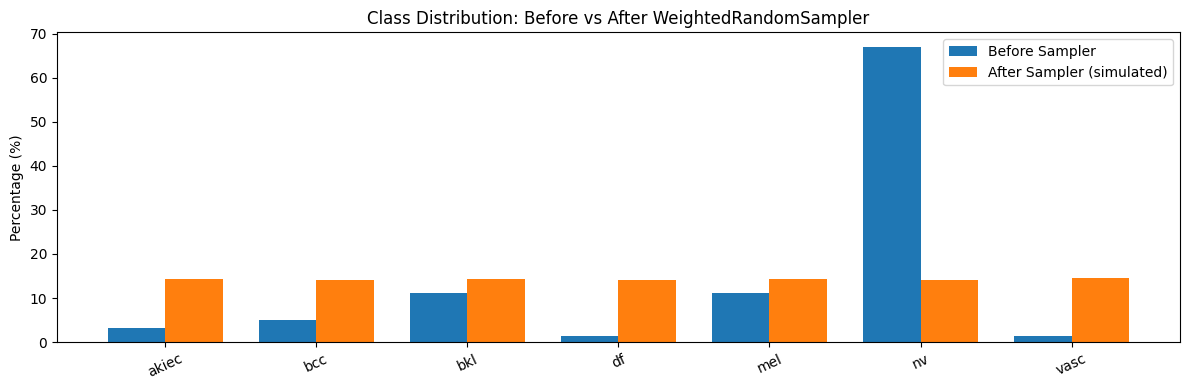

In [50]:
# =========================
# Cell 10 — Sampler weights + plot
# =========================
def plot_before_after_sampler_distribution(train_df, classes, sample_weights, n_draws=20000):
    ys = train_df["y"].values

    # Before
    before_counts = Counter(ys)
    before = np.array([before_counts.get(i, 0) for i in range(len(classes))], dtype=float)
    before_pct = before / (before.sum() + 1e-9) * 100

    # After (simulate draws)
    w = np.asarray(sample_weights, dtype=float)
    w = w / (w.sum() + 1e-12)
    draw_idx = np.random.choice(np.arange(len(ys)), size=int(n_draws), replace=True, p=w)
    sampled_y = ys[draw_idx]

    after_counts = Counter(sampled_y)
    after = np.array([after_counts.get(i, 0) for i in range(len(classes))], dtype=float)
    after_pct = after / (after.sum() + 1e-9) * 100

    x = np.arange(len(classes))
    width = 0.38
    plt.figure(figsize=(12, 4))
    plt.bar(x - width/2, before_pct, width, label="Before Sampler")
    plt.bar(x + width/2, after_pct, width, label="After Sampler (simulated)")
    plt.xticks(x, classes, rotation=25)
    plt.ylabel("Percentage (%)")
    plt.title("Class Distribution: Before vs After WeightedRandomSampler")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Build sample_weights
class_counts = train_df["y"].value_counts().sort_index().reindex(range(len(CFG.CLASSES)), fill_value=0).values
inv_freq = 1.0 / (class_counts + 1e-6)
sample_weights = train_df["y"].map(lambda y: inv_freq[int(y)]).values

print("Class counts:", class_counts)
plot_before_after_sampler_distribution(train_df, CFG.CLASSES, sample_weights, n_draws=20000)

## Cell 11 — Transforms


In [51]:
# =========================
# Cell 11 — Transforms
# =========================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

tfm_eval = T.Compose([
    T.Resize((CFG.img_size, CFG.img_size)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def get_train_transform(policy: str):
    policy = str(policy).lower().strip()
    if policy == "strong":
        return T.Compose([
            T.RandomResizedCrop(CFG.img_size, scale=(0.85, 1.0), ratio=(0.90, 1.10)),
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.5),
            T.RandomRotation(20),
            T.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.08, hue=0.0),
            T.ToTensor(),
            T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return T.Compose([
        T.RandomResizedCrop(CFG.img_size, scale=(0.90, 1.0), ratio=(0.95, 1.05)),
        T.RandomHorizontalFlip(p=0.5),
        T.RandomVerticalFlip(p=0.2),
        T.RandomRotation(15),
        T.ColorJitter(brightness=0.08, contrast=0.08, saturation=0.05, hue=0.0),
        T.ToTensor(),
        T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

print("✅ Transforms ready")

✅ Transforms ready


## Cell 12 — Dataset


In [52]:
# =========================
# Cell 12 — Dataset
# =========================
class HamDataset(Dataset):
    def __init__(self, df, tfm, return_path: bool):
        self.df = df.reset_index(drop=True)
        self.tfm = tfm
        self.return_path = bool(return_path)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        path = row["path"]
        y = int(row["y"])

        img = Image.open(path).convert("RGB")
        x = self.tfm(img)
        y = torch.tensor(y, dtype=torch.long)

        if self.return_path:
            return x, y, path
        return x, y

print("✅ Dataset ready")

✅ Dataset ready


## Cell 13 — DataLoaders factory (sampler ON for ladder)


In [53]:
# =========================
# Cell 13 — DataLoaders factory (sampler ON for ladder)
# =========================
using_drive = IN_COLAB and str(train_df["path"].iloc[0]).startswith("/content/drive")
num_workers = CFG.num_workers_drive if using_drive else CFG.num_workers_local
pin_memory = (device.type == "cuda")
persistent_workers = (num_workers > 0)

print("using_drive:", using_drive)
print("num_workers:", num_workers)
print("pin_memory:", pin_memory)
print("persistent_workers:", persistent_workers)

def make_train_loader(policy: str, use_sampler: bool = True):
    train_ds = HamDataset(train_df, get_train_transform(policy), return_path=False)

    if not use_sampler:
        return DataLoader(train_ds, batch_size=CFG.batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=pin_memory, persistent_workers=persistent_workers)

    class_counts = train_df["y"].value_counts().sort_index().reindex(range(len(CFG.CLASSES)), fill_value=0).values
    inv = 1.0 / (class_counts + 1e-6)
    sw = train_df["y"].map(lambda y: inv[int(y)]).values
    sampler = WeightedRandomSampler(torch.DoubleTensor(sw), num_samples=len(sw), replacement=True)

    return DataLoader(train_ds, batch_size=CFG.batch_size, sampler=sampler,
                      num_workers=num_workers, pin_memory=pin_memory, persistent_workers=persistent_workers)

val_loader = DataLoader(HamDataset(val_df, tfm_eval, return_path=False),
                        batch_size=CFG.batch_size, shuffle=False,
                        num_workers=num_workers, pin_memory=pin_memory, persistent_workers=persistent_workers)

test_loader = DataLoader(HamDataset(test_df, tfm_eval, return_path=True),
                         batch_size=CFG.batch_size, shuffle=False,
                         num_workers=num_workers, pin_memory=pin_memory, persistent_workers=persistent_workers)

print("✅ Loaders ready")

using_drive: False
num_workers: 2
pin_memory: True
persistent_workers: True
✅ Loaders ready


## Cell 14 — Transfer-learning model (ResNet50, Grad-CAM safe) — Listing 4.3 source


In [ ]:

# Cell 14 — Transfer Learning Model (Grad-CAM safe)

class TLModel(nn.Module):
    def __init__(self, num_classes: int, backbone_name: str="resnet50", pretrained: bool=True):
        super().__init__()

        if backbone_name != "resnet50":
            raise ValueError("Only resnet50 supported here for a fair, stable baseline.")

        weights = models.ResNet50_Weights.DEFAULT if pretrained else None
        backbone = models.resnet50(weights=weights)

        # disable inplace ReLU (fix Grad-CAM hook issues)
        for m in backbone.modules():
            if isinstance(m, nn.ReLU):
                m.inplace = False

        in_features = backbone.fc.in_features
        backbone.fc = nn.Identity()

        self.backbone = backbone
        self.head = nn.Linear(in_features, num_classes)

        # Grad-CAM target layer (last conv)
        self.cam_target = self.backbone.layer4[-1].conv3

    def forward(self, x):
        feats = self.backbone(x)
        return self.head(feats)

print("✅ TLModel ready:", CFG.backbone_name)

✅ TLModel ready: resnet50


## Cell 15 — Optimiser + criterion (differential LR)


In [57]:
# =========================
# Cell 15 — Optimizer + Criterion
# =========================
def make_optimizer(model: TLModel):
    params = [
        {"params": model.backbone.parameters(), "lr": CFG.lr_backbone},
        {"params": model.head.parameters(), "lr": CFG.lr_head},
    ]
    return torch.optim.AdamW(params, weight_decay=CFG.weight_decay)

def make_criterion():
    return nn.CrossEntropyLoss(label_smoothing=float(CFG.label_smoothing))

print("✅ Optimizer & loss ready")

✅ Optimizer & loss ready


## Cell 16 — Train / eval loops


In [58]:
# =========================
# Cell 16 — Train / Eval
# =========================
from torch.amp import autocast, GradScaler

class EMA:
    def __init__(self, decay: float = 0.999):
        self.decay = float(decay)
        self.shadow = {}

    @torch.no_grad()
    def init(self, model):
        self.shadow = {k: v.detach().clone() for k, v in model.state_dict().items()}

    @torch.no_grad()
    def update(self, model):
        if not self.shadow:
            self.init(model)
            return
        msd = model.state_dict()
        for k, v in msd.items():
            if v.dtype.is_floating_point:
                self.shadow[k].mul_(self.decay).add_(v.detach(), alpha=(1 - self.decay))
            else:
                self.shadow[k] = v.detach().clone()

def mixup_batch(x, y, alpha: float):
    if alpha <= 0:
        return x, y, y, 1.0
    dist = torch.distributions.Beta(alpha, alpha)
    lam = float(dist.sample().to(x.device))
    lam = 1.0 - lam if lam < 0.5 else lam
    idx = torch.randperm(x.size(0), device=x.device)
    x2, y2 = x[idx], y[idx]
    xm = lam * x + (1 - lam) * x2
    return xm, y, y2, lam

def train_one_epoch(model, loader, opt, scaler, criterion, ema=None):
    model.train()
    total = 0.0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        opt.zero_grad(set_to_none=True)

        if CFG.use_mixup:
            x_in, y1, y2, lam = mixup_batch(x, y, CFG.mixup_alpha)
        else:
            x_in, y1, y2, lam = x, y, y, 1.0

        with autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = model(x_in)
            if CFG.use_mixup:
                loss = lam * criterion(logits, y1) + (1 - lam) * criterion(logits, y2)
            else:
                loss = criterion(logits, y1)

        scaler.scale(loss).backward()
        scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.clip_grad)
        scaler.step(opt)
        scaler.update()

        if ema is not None:
            ema.update(model)

        total += loss.item() * x.size(0)

    return total / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    ys, ps, paths = [], [], []
    total = 0.0

    for batch in loader:
        if len(batch) == 3:
            x, y, p = batch
            paths.extend(list(p))
        else:
            x, y = batch

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)
        total += loss.item() * x.size(0)

        pred = logits.argmax(1)
        ys.extend(y.cpu().numpy())
        ps.extend(pred.cpu().numpy())

    ys = np.array(ys); ps = np.array(ps)
    acc = float((ys == ps).mean())
    bacc = float(balanced_accuracy_score(ys, ps))
    f1 = float(f1_score(ys, ps, average="weighted"))
    cm = confusion_matrix(ys, ps)
    return total / len(loader.dataset), acc, bacc, f1, cm, ys, ps, paths

def run_experiment(tag, aug_policy, epochs=CFG.epochs, patience=CFG.patience):
    seed_everything(CFG.seed)

    model = TLModel(len(CFG.CLASSES), CFG.backbone_name, CFG.pretrained).to(device)
    opt = make_optimizer(model)
    criterion = make_criterion()
    scaler = GradScaler("cuda") if device.type == "cuda" else GradScaler("cpu")
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    ema = EMA(CFG.ema_decay) if CFG.use_ema else None

    best_bacc = -1.0
    bad = 0
    best_path = str(CFG.RUN_DIR / f"best_{tag}.pt")
    hist = []

    train_loader = make_train_loader(policy=aug_policy, use_sampler=True)

    for ep in range(1, epochs + 1):
        tr_loss = train_one_epoch(model, train_loader, opt, scaler, criterion, ema=ema)
        va_loss, va_acc, va_bacc, va_f1, _, _, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()

        hist.append([ep, tr_loss, va_loss, va_acc, va_bacc, va_f1])

        if va_bacc > best_bacc + 1e-4:
            best_bacc = va_bacc
            torch.save((ema.shadow if (ema is not None and ema.shadow) else model.state_dict()), best_path)
            bad = 0
        else:
            bad += 1

        print(f"[{tag}] ep {ep:02d} | tr_loss {tr_loss:.4f} | val_loss {va_loss:.4f} | "
              f"val_acc {va_acc:.4f} | val_bacc {va_bacc:.4f} | val_f1 {va_f1:.4f} | bad={bad}")

        if bad >= patience:
            print(f"🛑 Early stopping: no val_bacc improvement for {patience} epochs.")
            break

    hist_df = pd.DataFrame(hist, columns=["epoch","train_loss","val_loss","val_acc","val_bacc","val_f1"])
    hist_df.to_csv(CFG.RUN_DIR / f"history_{tag}.csv", index=False)
    print("✅ Best val_bacc:", best_bacc, "| saved:", best_path)

    return hist_df, best_path

print("✅ Train/Eval ready")

✅ Train/Eval ready


## Cell 17 — Ladder definition B0 → B4


In [59]:
# =========================
# Cell 17 — Ladder definition
# =========================
LADDER = [
    ("B0_sampler_light",    "light",  False, 0.00, False),
    ("B1_sampler_strong",   "strong", False, 0.00, False),
    ("B2_strong_mixup",     "strong", True,  0.00, False),
    ("B3_mixup_smoothing",  "strong", True,  0.05, False),
    ("B4_mixup_smooth_ema", "strong", True,  0.05, True ),
]
print("✅ Ladder ready:", [x[0] for x in LADDER])

✅ Ladder ready: ['B0_sampler_light', 'B1_sampler_strong', 'B2_strong_mixup', 'B3_mixup_smoothing', 'B4_mixup_smooth_ema']


## Cell 18 — Run the ladder (B0 → B4)


In [60]:
# =========================
# Cell 18 — Run ladder
# =========================
all_hist = {}
all_best = {}

for tag, aug_policy, use_mixup, ls, use_ema in LADDER:
    print("\n" + "="*100)
    print("RUN:", tag, "| aug:", aug_policy, "| mixup:", use_mixup, "| ls:", ls, "| ema:", use_ema)
    print("="*100)

    CFG.AUG_POLICY = aug_policy
    CFG.use_mixup = bool(use_mixup)
    CFG.label_smoothing = float(ls)
    CFG.use_ema = bool(use_ema)

    hist_df, best_path = run_experiment(tag, aug_policy, epochs=CFG.epochs, patience=CFG.patience)
    all_hist[tag] = hist_df
    all_best[tag] = best_path

print("\n✅ Ladder complete.")
for k,v in all_best.items():
    print(k, "->", v)


RUN: B0_sampler_light | aug: light | mixup: False | ls: 0.0 | ema: False
[B0_sampler_light] ep 01 | tr_loss 0.8327 | val_loss 0.6839 | val_acc 0.7565 | val_bacc 0.6586 | val_f1 0.7669 | bad=0
[B0_sampler_light] ep 02 | tr_loss 0.3503 | val_loss 0.7188 | val_acc 0.7473 | val_bacc 0.6974 | val_f1 0.7660 | bad=0
[B0_sampler_light] ep 03 | tr_loss 0.2540 | val_loss 0.6987 | val_acc 0.7741 | val_bacc 0.6539 | val_f1 0.7865 | bad=1
[B0_sampler_light] ep 04 | tr_loss 0.2089 | val_loss 0.7312 | val_acc 0.8040 | val_bacc 0.6648 | val_f1 0.8053 | bad=2
[B0_sampler_light] ep 05 | tr_loss 0.1846 | val_loss 0.6771 | val_acc 0.8002 | val_bacc 0.6646 | val_f1 0.8076 | bad=3
[B0_sampler_light] ep 06 | tr_loss 0.1537 | val_loss 0.7521 | val_acc 0.7871 | val_bacc 0.6126 | val_f1 0.7945 | bad=4
[B0_sampler_light] ep 07 | tr_loss 0.1337 | val_loss 0.7396 | val_acc 0.7910 | val_bacc 0.6745 | val_f1 0.7985 | bad=5
[B0_sampler_light] ep 08 | tr_loss 0.1196 | val_loss 0.6912 | val_acc 0.8346 | val_bacc 0.650

## Cell 19 — Per-rung curves (Figure 4.4 source)


✅ Plotting curves for: TransferLearning-resnet50


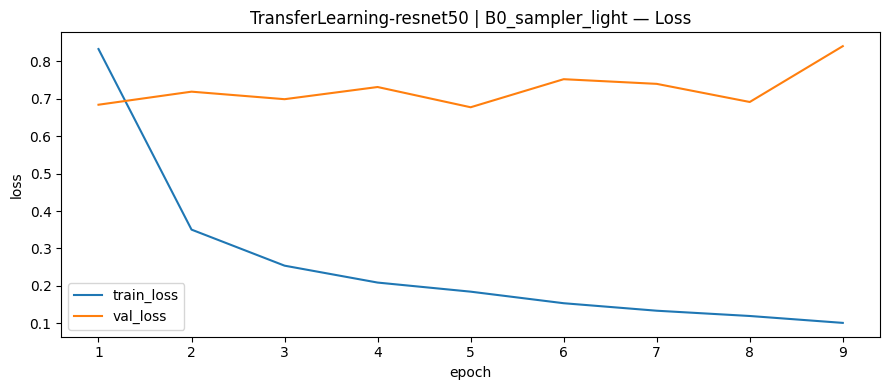

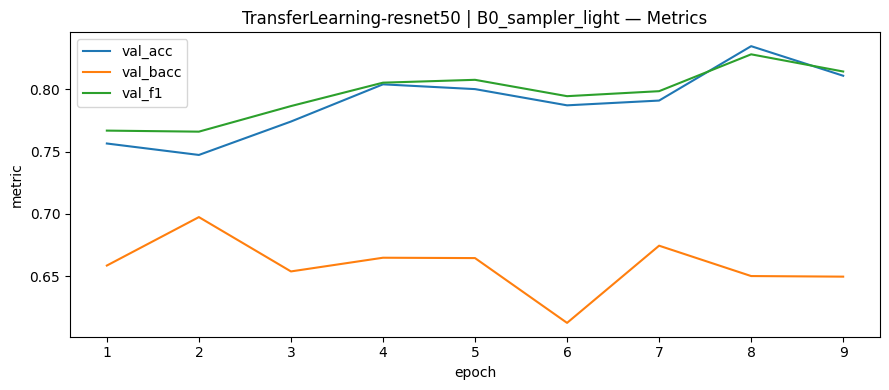

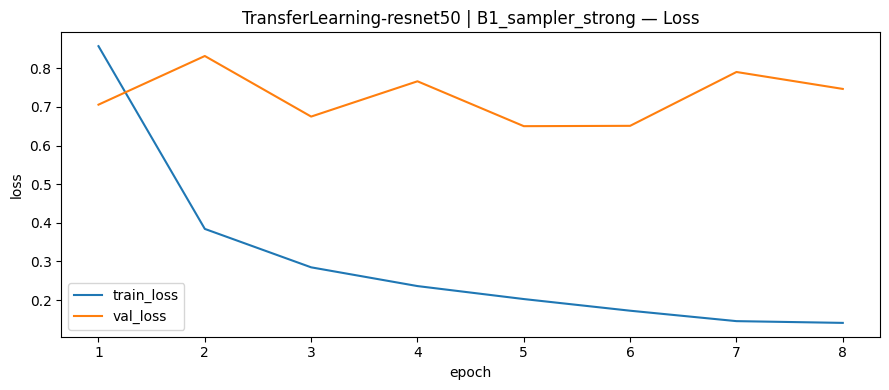

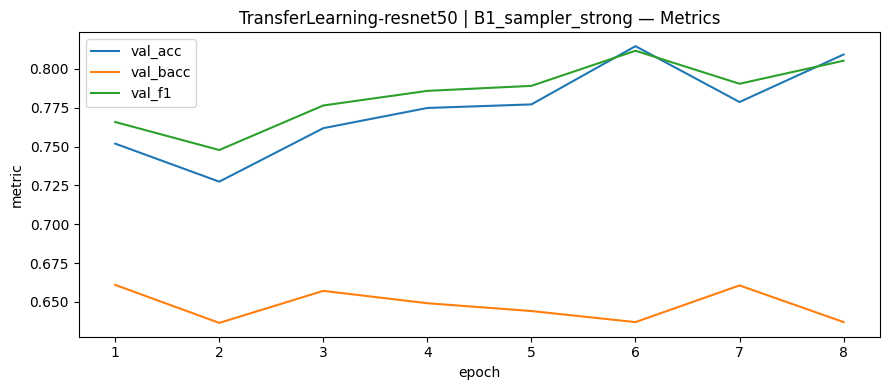

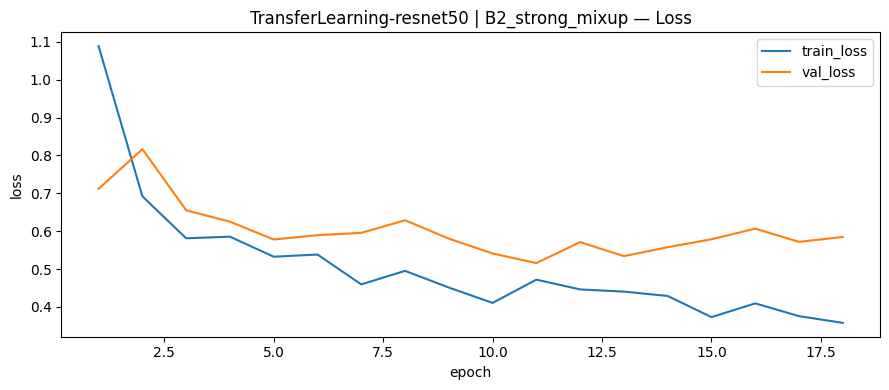

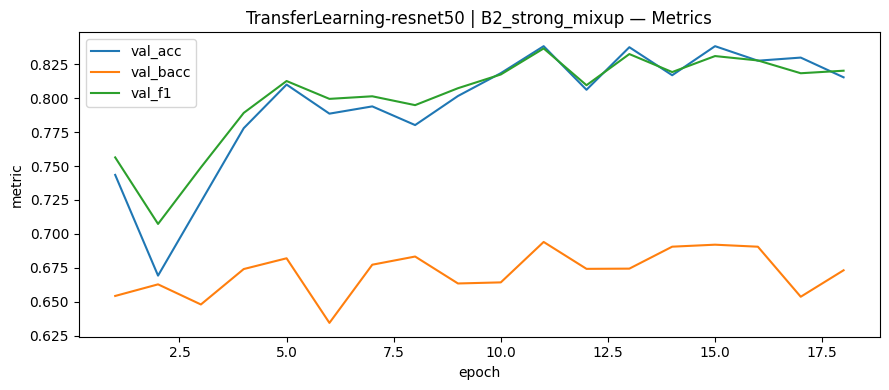

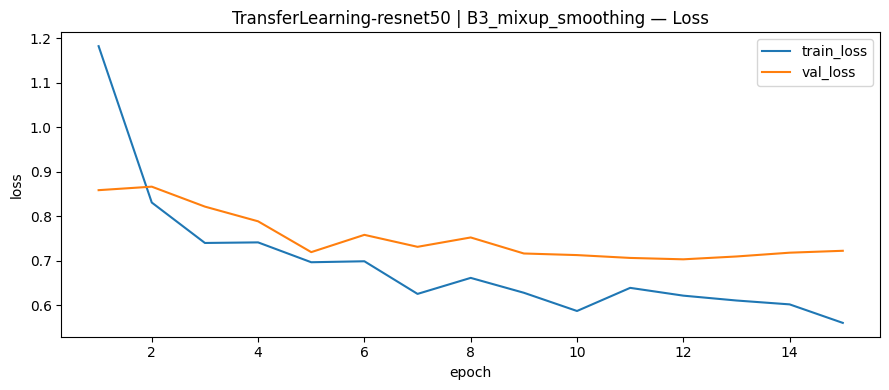

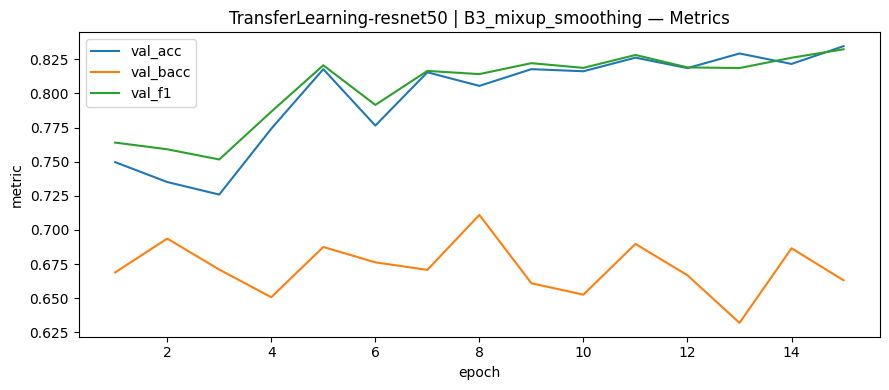

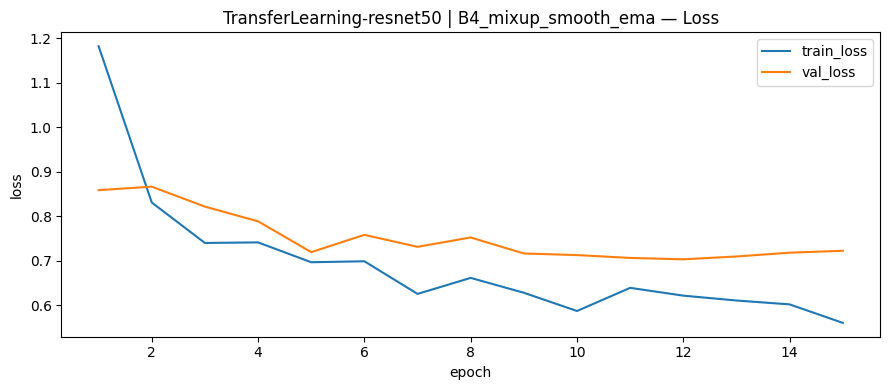

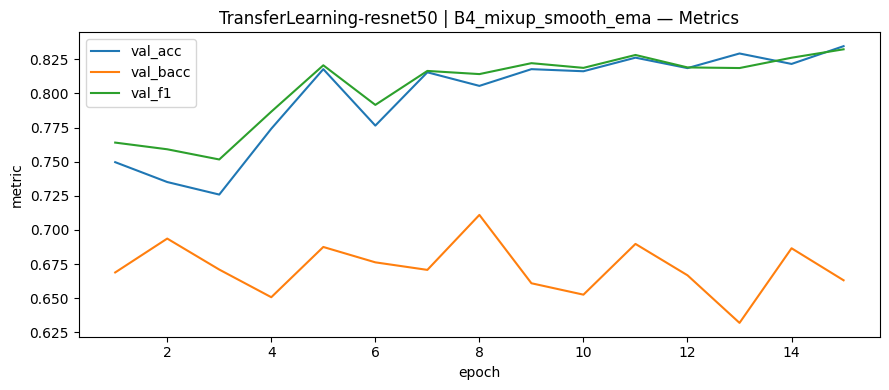

In [61]:
# =========================
# Cell 18.5 — Curves for each experiment (with model name)
# =========================
import matplotlib.pyplot as plt

def plot_history_df(hist_df, title_prefix=""):
    # Loss
    plt.figure(figsize=(9,4))
    plt.plot(hist_df["epoch"], hist_df["train_loss"], label="train_loss")
    plt.plot(hist_df["epoch"], hist_df["val_loss"], label="val_loss")
    plt.title(f"{title_prefix} — Loss")
    plt.xlabel("epoch"); plt.ylabel("loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Metrics
    plt.figure(figsize=(9,4))
    plt.plot(hist_df["epoch"], hist_df["val_acc"], label="val_acc")
    plt.plot(hist_df["epoch"], hist_df["val_bacc"], label="val_bacc")
    plt.plot(hist_df["epoch"], hist_df["val_f1"], label="val_f1")
    plt.title(f"{title_prefix} — Metrics")
    plt.xlabel("epoch"); plt.ylabel("metric")
    plt.legend()
    plt.tight_layout()
    plt.show()

MODEL_NAME = f"TransferLearning-{CFG.backbone_name}"
print("✅ Plotting curves for:", MODEL_NAME)

for tag, hist_df in all_hist.items():
    title = f"{MODEL_NAME} | {tag}"
    plot_history_df(hist_df, title_prefix=title)

## Cell 20 — TEST evaluation + summary (Tables 4.4, 4.5 source)



✅ TEST EVALUATION — Model: TransferLearning-resnet50 (pretrained=True)

----------------------------------------------------------------------------------------------------
MODEL: TransferLearning-resnet50 | RUN: B0_sampler_light
CKPT : /content/drive/MyDrive/ham_runs/notebook2_transfer_learning_matched_recipe/best_B0_sampler_light.pt
TEST : loss=0.9750 acc=0.7315 bacc=0.7424 f1=0.7537
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       akiec     0.3404    0.6667    0.4507        48
         bcc     0.5000    0.7879    0.6118        66
         bkl     0.5686    0.6744    0.6170       172
          df     0.4706    0.8000    0.5926        10
         mel     0.4342    0.6559    0.5225       186
          nv     0.9670    0.7500    0.8448      1016
        vasc     0.6410    0.8621    0.7353        29

    accuracy                         0.7315      1527
   macro avg     0.56

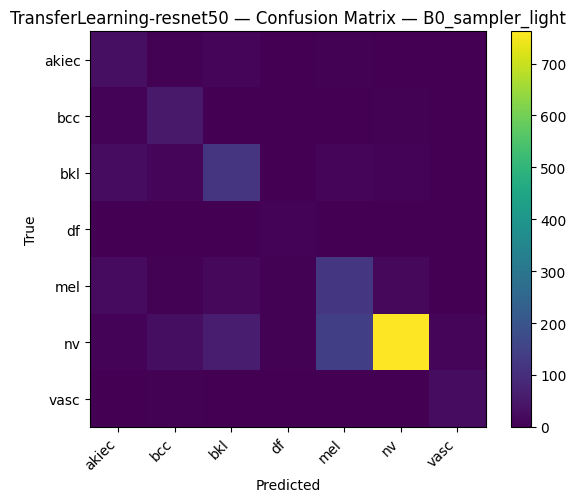


----------------------------------------------------------------------------------------------------
MODEL: TransferLearning-resnet50 | RUN: B1_sampler_strong
CKPT : /content/drive/MyDrive/ham_runs/notebook2_transfer_learning_matched_recipe/best_B1_sampler_strong.pt
TEST : loss=0.9549 acc=0.7269 bacc=0.6916 f1=0.7476
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       akiec     0.2868    0.7708    0.4181        48
         bcc     0.5248    0.8030    0.6347        66
         bkl     0.5528    0.5174    0.5345       172
          df     0.5556    0.5000    0.5263        10
         mel     0.4453    0.6129    0.5158       186
          nv     0.9448    0.7746    0.8513      1016
        vasc     0.6579    0.8621    0.7463        29

    accuracy                         0.7269      1527
   macro avg     0.5668    0.6916    0.6039      1527
weighted avg     0.7930    0.7269    

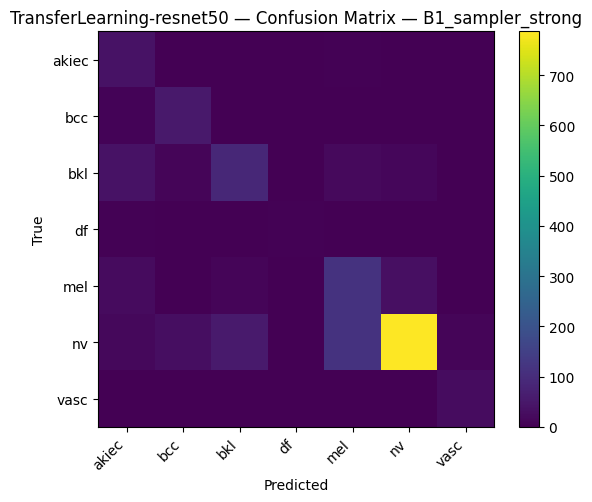


----------------------------------------------------------------------------------------------------
MODEL: TransferLearning-resnet50 | RUN: B2_strong_mixup
CKPT : /content/drive/MyDrive/ham_runs/notebook2_transfer_learning_matched_recipe/best_B2_strong_mixup.pt
TEST : loss=0.7152 acc=0.8251 bacc=0.7789 f1=0.8242
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       akiec     0.4677    0.6042    0.5273        48
         bcc     0.6667    0.7576    0.7092        66
         bkl     0.7239    0.6860    0.7045       172
          df     0.8333    1.0000    0.9091        10
         mel     0.6125    0.5269    0.5665       186
          nv     0.9115    0.9124    0.9120      1016
        vasc     0.7368    0.9655    0.8358        29

    accuracy                         0.8251      1527
   macro avg     0.7075    0.7789    0.7378      1527
weighted avg     0.8256    0.8251    0.82

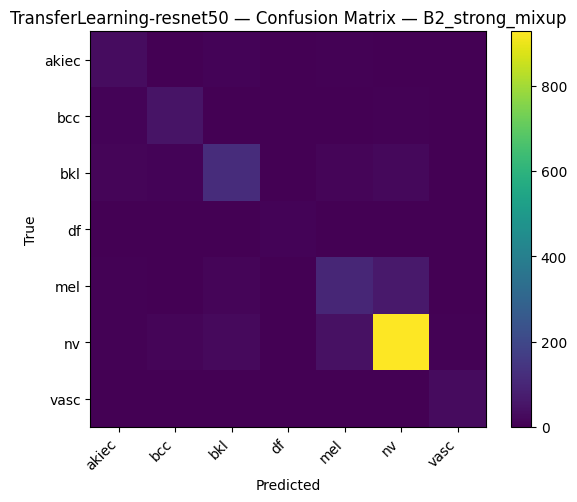


----------------------------------------------------------------------------------------------------
MODEL: TransferLearning-resnet50 | RUN: B3_mixup_smoothing
CKPT : /content/drive/MyDrive/ham_runs/notebook2_transfer_learning_matched_recipe/best_B3_mixup_smoothing.pt
TEST : loss=0.7749 acc=0.7944 bacc=0.7584 f1=0.8034
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       akiec     0.5333    0.5000    0.5161        48
         bcc     0.5934    0.8182    0.6879        66
         bkl     0.5702    0.7791    0.6585       172
          df     0.6154    0.8000    0.6957        10
         mel     0.5381    0.6075    0.5707       186
          nv     0.9520    0.8386    0.8917      1016
        vasc     0.7368    0.9655    0.8358        29

    accuracy                         0.7944      1527
   macro avg     0.6485    0.7584    0.6938      1527
weighted avg     0.8236    0.7944  

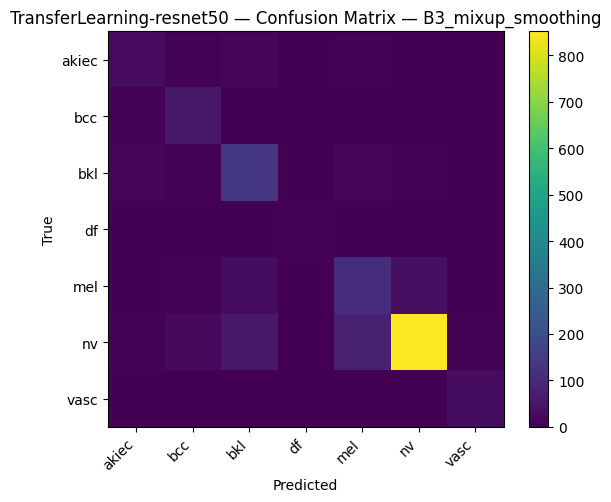


----------------------------------------------------------------------------------------------------
MODEL: TransferLearning-resnet50 | RUN: B4_mixup_smooth_ema
CKPT : /content/drive/MyDrive/ham_runs/notebook2_transfer_learning_matched_recipe/best_B4_mixup_smooth_ema.pt
TEST : loss=0.7439 acc=0.8081 bacc=0.7386 f1=0.8019
----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

       akiec     0.3793    0.6875    0.4889        48
         bcc     0.5889    0.8030    0.6795        66
         bkl     0.8148    0.5116    0.6286       172
          df     0.3600    0.9000    0.5143        10
         mel     0.6522    0.4032    0.4983       186
          nv     0.8902    0.9341    0.9116      1016
        vasc     0.7500    0.9310    0.8308        29

    accuracy                         0.8081      1527
   macro avg     0.6336    0.7386    0.6503      1527
weighted avg     0.8175    0.8081

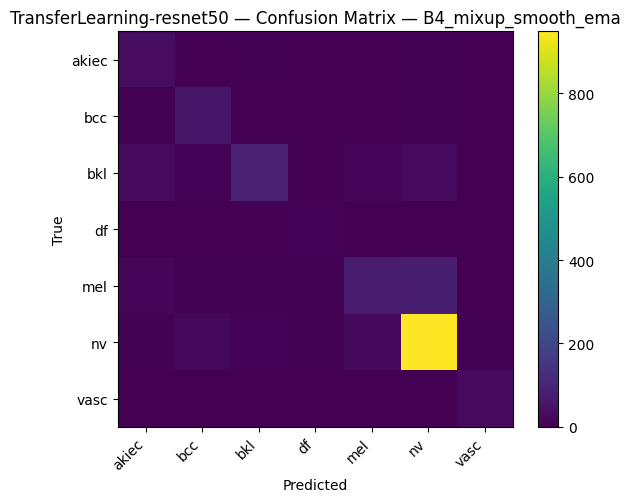


=== TEST Summary (sorted by f1) ===


,model_name,tag,acc,bacc,f1,loss
0,TransferLearning-resnet50,B2_strong_mixup,0.825147,0.778941,0.824182,0.715237
1,TransferLearning-resnet50,B3_mixup_smoothing,0.794368,0.758411,0.803358,0.774903
2,TransferLearning-resnet50,B4_mixup_smooth_ema,0.808120,0.738639,0.801940,0.743936
3,TransferLearning-resnet50,B0_sampler_light,0.731500,0.742421,0.753684,0.974964
4,TransferLearning-resnet50,B1_sampler_strong,0.726916,0.691555,0.747637,0.954902


✅ Saved: /content/drive/MyDrive/ham_runs/notebook2_transfer_learning_matched_recipe/test_summary.csv


In [62]:
# =========================
# Cell 19 — TEST evaluation + summary (with model name saved)
# =========================
import matplotlib.pyplot as plt

MODEL_NAME = f"TransferLearning-{CFG.backbone_name}"

def load_ckpt(model, ckpt_path: str):
    sd = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(sd, strict=True)
    return model

def plot_cm(cm, title, labels):
    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap="viridis")
    plt.title(title)
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(range(len(labels)), labels)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

results = []
crit = make_criterion()

print("\n" + "="*100)
print(f"✅ TEST EVALUATION — Model: {MODEL_NAME} (pretrained={CFG.pretrained})")
print("="*100)

for tag, ckpt in all_best.items():
    model = TLModel(len(CFG.CLASSES), CFG.backbone_name, CFG.pretrained).to(device)
    model = load_ckpt(model, ckpt)

    loss, acc, bacc, f1, cm, ys, ps, _ = evaluate(model, test_loader, crit)

    print("\n" + "-"*100)
    print(f"MODEL: {MODEL_NAME} | RUN: {tag}")
    print(f"CKPT : {ckpt}")
    print(f"TEST : loss={loss:.4f} acc={acc:.4f} bacc={bacc:.4f} f1={f1:.4f}")
    print("-"*100)

    print(classification_report(ys, ps, target_names=CFG.CLASSES, digits=4))
    plot_cm(cm, f"{MODEL_NAME} — Confusion Matrix — {tag}", CFG.CLASSES)

    results.append({
        "model_name": MODEL_NAME,
        "backbone_name": CFG.backbone_name,
        "pretrained": bool(CFG.pretrained),
        "tag": tag,
        "acc": acc,
        "bacc": bacc,
        "f1": f1,
        "loss": loss,
        "ckpt": ckpt
    })

res_df = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)

print("\n=== TEST Summary (sorted by f1) ===")
try:
    display(res_df[["model_name","tag","acc","bacc","f1","loss"]])
except Exception:
    print(res_df[["model_name","tag","acc","bacc","f1","loss"]])

save_path = CFG.RUN_DIR / "test_summary.csv"
res_df.to_csv(save_path, index=False)
print("✅ Saved:", save_path)